<a href="https://colab.research.google.com/github/rumijay/Data-Science-2025/blob/main/Rumi_Unit7ExercisesSF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fitting Curves: Concepts

What you'll do:

- Answer questions about what a GP is, and its relationship to GLMs and splines.
- Practice applying each of: polynomial modeling, b splines, and GPs
- You'll get a chance to read about and try to comprehend a more standard implementation of a GP.

Have fun!

**Task1**:

Why would you ever want to include a polynomial element in a model you built? What's the benefit of using polynomials to model?

It allows you to capture non-linear relationships between variables, enabling a simple linear model to fit complex, curved data trends more accurately

**Task2**:

Why would you ever NOT want to include a polynomial element in a model you built?

to prevent severe overfitting (modeling noise instead of trends), high collinearity among features, and poor generalization to new data

**Task3**:

What's the point of using b splines?

They are useful bcuz modifying a single control point only affects a small, nearby section of the curve, not the entire shape.

**Task4**:

Describe what a Gaussian Process is, in your own words. *Don't worry about being correct, just try to explain it to yourself*. I will not grade this question for accuracy.

it's way of modelinng a function by thinking about it as a flexible curve rather than a fixed formulas with

**Task5**:

Fit three models to the howell data (from Unit5ExercisesSF): polynomial, b splines, and Gaussian Process.

Plot the posterior predictive check on a scatter plot, as is standard/required.

Hint: Distributional models (variable variance) work better on the howell data.


In [ ]:

!pip install preliz
!pip install bambi


In [2]:

import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
import arviz as az
import xarray as xr
import pymc as pm
from scipy.interpolate import PchipInterpolator
import bambi as bmb
import preliz as pz

In [3]:
howell = pd.read_csv('https://raw.githubusercontent.com/thedarredondo/data-science-fundamentals/main/Data/howell.csv')

In [ ]:
model_poly_3 = bmb.Model("weight ~ poly(height, degree=3)", howell, family="negativebinomial")
idata_poly_3 = model_poly_3.fit()

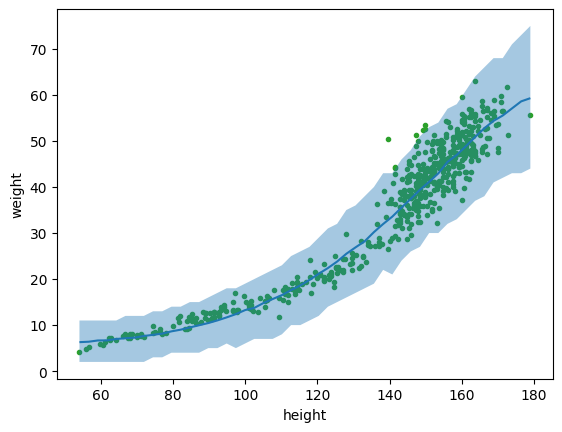

In [5]:
#plot of posterior predictive dist
bmb.interpret.plot_predictions(model_poly_3, idata_poly_3, "height", pps=True)
#raw data
plt.plot(howell.height, howell.weight, "C2.", zorder=-3)


In [ ]:
num_knots = 6
knots = np.linspace(howell.height.min(), howell.height.max(), num_knots+2)[1:-1]
model_spline_t = bmb.Model("weight ~ bs(height, degree=3, knots=knots)", howell, family="negativebinomial")
idata_spline_t = model_spline_t.fit()

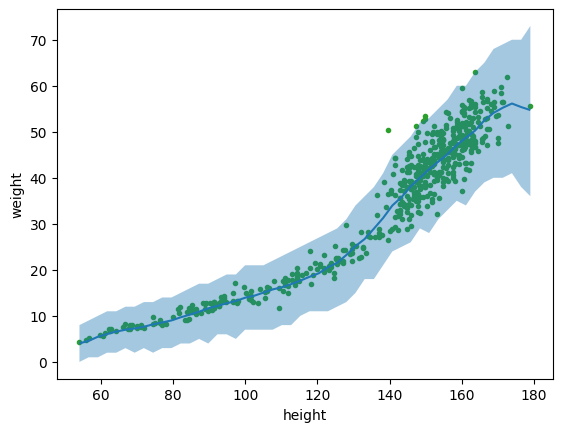

In [7]:

bmb.interpret.plot_predictions(model_spline_t, idata_spline_t, "height", pps= True)
plt.plot(howell.height, howell.weight, "C2.", zorder=-3)

In [ ]:
def get_ig_params(data):
 #used gemini for this cuz the code in the notes wasnt working
    data_range = data.max() - data.min()
    mean_ell = data_range / 5
    alpha = 2
    beta = mean_ell * (alpha - 1)
    return {"alpha": alpha, "beta": beta}

prior_gp = {
    "sigma": bmb.Prior("Gamma", mu=1, sigma=0.01),
    "ell": bmb.Prior("InverseGamma", **get_ig_params(howell.height))
}

priors = {
    "hsgp(height, m=168, c=8.0)": prior_gp,
    "alpha": bmb.Prior("HalfNormal", sigma=1)
}

model_hsb = bmb.Model("weight ~ 0 + hsgp(height, m=168, c=8.0)", howell, family="negativebinomial", priors=priors)
idata_hsb = model_hsb.fit(nuts_kwargs={'target_accept': 0.99})

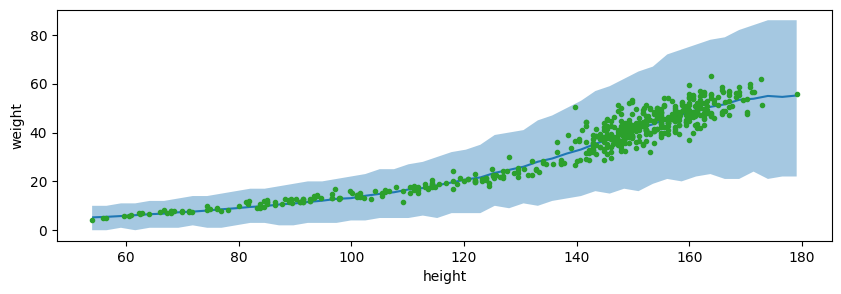

In [13]:

_, ax = bmb.interpret.plot_predictions(model_hsb, idata_hsb, ["height"],
                                       pps = True,
                                       fig_kwargs={"figsize": (10, 3)})
ax[0].plot(howell["height"].values, howell["weight"].values, "C2.")

**Task6**:

Read the article on the pymc website about GP implementation on the Mauna Loa CO$_{2}$ data combined with CO$_{2}$ ice core data from the south pole.
[Link here.](https://www.pymc.io/projects/examples/en/latest/gaussian_processes/GP-MaunaLoa2.html)

Write down one thing you learned about GPs from reading the article.

Note: You probably won't understand much in this article--I had to read it about five times before I figured out what was going on. The points of this task are to: hammer home that good GP implementations are extremely technical, and increasure your exposure to the kinds of problems traditional GPs are good at solving.

One thing I learned is that Gaussian Processes can explicitly model uncertainty in the input variable (x), not just in the outputs (y).

**Task7**:

Describe your favorite graph from the article in the previous task with as much technical detail as you can muster.

Explain why its your favorite.